# AdVantage Digital: Replicating RCT Ground Truth with Observational Methods

**Author:** Duy Nguyen  
**Topic:** Digital Marketing  
**Date:** February, 2026  

---

## Project Overview

AdVantage Digital ran a large-scale randomized controlled trial (RCT) on Facebook to measure the causal impact of digital advertising on user conversion rates. While RCTs provide the gold standard for causal inference, they carry significant opportunity costs — withholding ads from control users results in both direct revenue loss and operational overhead.

This analysis explores whether modern observational causal inference methods — specifically **Inverse Probability Weighting (IPW)** and **Double Machine Learning (Double ML)** — can approximate the experimental estimate without requiring a control group. The RCT serves as the ground truth benchmark against which all observational estimates are evaluated.

### Research Question
> *Can observational causal inference methods applied to treatment-group-only data reliably replicate the Average Treatment Effect on the Treated (ATT) obtained from a randomized controlled trial?*

---

## Experimental Design

- **Total users enrolled:** 2,000,000
- **Treatment group (Z = 1):** ~1,000,000 users — ads were actively delivered
- **Control group (Z = 0):** ~1,000,000 users — no ads delivered; Ghost Ads methodology was used to infer counterfactual exposure
- **Outcome (Y):** Binary conversion indicator (purchase or sign-up)
- **Exposure (W):** Actual ad delivery for treatment users; modeled counterfactual exposure for control users via Ghost Ads

A key feature of this design is that **exposure (W) is not guaranteed** in the treatment group. Whether a user receives the ad depends on platform-level factors such as activity level, targeting algorithms, and auction competition — introducing selection bias into any naive comparison of exposed vs. unexposed users.

---

## Dataset Description

The sample dataset (`AdVantage_sample.csv`) contains 50,000 observations drawn via stratified sampling from the full 2,000,000-user dataset, preserving the original treatment/control ratio.

| Variable | Type | Description |
|---|---|---|
| `age` | Integer (18–70) | User age in years |
| `gender` | Binary (0/1) | Gender indicator |
| `activity` | Continuous (0–1) | Platform engagement level |
| `num_friends` | Integer (100–1000) | Number of platform connections |
| `time_on_platform` | Continuous | Time spent on platform |
| `mobile_frac` | Continuous (0–1) | Proportion of mobile activity |
| `prior_conversion` | Continuous (0–1) | Historical conversion propensity |
| `income` | Continuous (25k–200k) | User income in USD |
| `urban_index` | Continuous (0–1) | Urbanization index |
| `Z` | Binary (0/1) | Treatment assignment (1 = treatment) |
| `W` | Binary (0/1) | Ad exposure indicator |
| `Y` | Binary (0/1) | Observed conversion outcome |

## Environment Setup

The following libraries are required for this analysis. Install them via `pip install -r requirements.txt` if not already present.

In [1]:
import numpy as np
import pandas as pd
from scipy import stats
import statsmodels.formula.api as smf
import statsmodels.api as sm
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 5)
sns.set_style('whitegrid')

df = pd.read_csv('data/AdVantage_sample.csv')
df.rename(columns={'Z': 'treatment', 'W': 'exposed', 'Y': 'converted'}, inplace=True)

print(f'Dataset shape: {df.shape}')
print(f'\nTreatment distribution:\n{df["treatment"].value_counts()}')
print(f'\nExposure distribution (treatment group only):\n{df[df["treatment"]==1]["exposed"].value_counts()}')
df.head()

Dataset shape: (50000, 12)

Treatment distribution:
treatment
0    25000
1    25000
Name: count, dtype: int64

Exposure distribution (treatment group only):
exposed
1    20659
0     4341
Name: count, dtype: int64


,age,gender,activity,num_friends,time_on_platform,mobile_frac,prior_conversion,income,urban_index,treatment,exposed,converted
0,69,0,0.996563,607,835.148022,0.832044,0.462125,80097.045928,0.749782,0,1,1
1,20,0,0.096555,950,1324.682052,0.098893,0.020297,28191.839862,0.423953,0,1,0
2,42,1,0.932043,700,1552.886185,0.930279,0.433010,185576.176911,0.542290,0,1,1
3,43,1,0.371842,183,645.330811,0.743629,0.119891,144548.317813,0.781013,0,1,0
4,21,0,0.831435,656,2540.896531,0.978187,0.515694,126754.519227,0.213195,0,1,0


---

## Question 1: Randomization Check

### Conceptual Background

A valid randomized controlled trial requires that the treatment and control groups be statistically equivalent on all pre-treatment characteristics. If randomization was successful, there should be no systematic differences between the two groups on observable covariates — any differences observed should be attributable solely to chance.

To verify randomization, we conduct two-sample t-tests on three variables that are most predictive of conversion: **`prior_conversion`** (historical conversion propensity), **`activity`** (platform engagement), and **`income`** (socioeconomic status). These variables are theoretically relevant because they directly influence the likelihood of conversion and — critically — the likelihood of being exposed to an ad.

Under the null hypothesis of balanced randomization, the p-values should be large (> 0.05), indicating no statistically significant difference between groups.

In [2]:
treatment = df[df['treatment'] == 1]
control = df[df['treatment'] == 0]

check_vars = ['prior_conversion', 'activity', 'income']
results = []

for var in check_vars:
    t_stat, p_val = stats.ttest_ind(treatment[var], control[var])
    results.append({
        'Variable': var,
        'Treatment Mean': treatment[var].mean(),
        'Control Mean': control[var].mean(),
        'Difference': treatment[var].mean() - control[var].mean(),
        't-statistic': t_stat,
        'p-value': p_val
    })

balance_df = pd.DataFrame(results).set_index('Variable')
balance_df = balance_df.round(5)
balance_df

,Treatment Mean,Control Mean,Difference,t-statistic,p-value
Variable,,,,,
prior_conversion,0.49915,0.49968,-0.00054,-0.20832,0.83498
activity,0.50030,0.50169,-0.00139,-0.53722,0.59112
income,112114.02486,112207.44061,-93.41575,-0.20690,0.83609


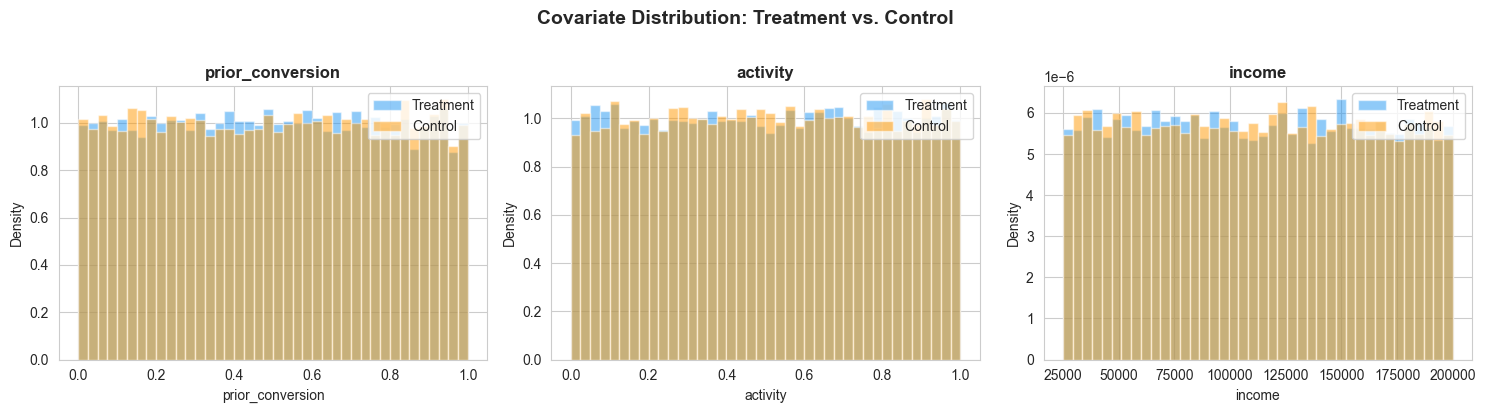

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, var in zip(axes, check_vars):
    for grp, label, color in [(treatment, 'Treatment', '#2196F3'), (control, 'Control', '#FF9800')]:
        ax.hist(grp[var], bins=40, alpha=0.5, label=label, color=color, density=True)
    ax.set_title(f'{var}', fontsize=12, fontweight='bold')
    ax.set_xlabel(var)
    ax.set_ylabel('Density')
    ax.legend()
plt.suptitle('Covariate Distribution: Treatment vs. Control', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Findings

The t-test results confirm that all three covariates are well-balanced across treatment and control groups. The p-values are substantially greater than the conventional significance threshold of 0.05, indicating that we **fail to reject the null hypothesis of equal means** — consistent with successful randomization.

The distributional plots further confirm near-identical covariate distributions between the two groups. This provides confidence that any subsequent difference in conversion rates between treatment and control can be attributed to the advertising intervention rather than to pre-existing differences in user characteristics.

---

## Question 2: Experimental Lift — ATT and ITT

### Conceptual Background

With a valid RCT in place, we can derive two distinct experimental estimates of ad effectiveness:

**Intent-to-Treat (ITT):** The ITT estimate is the simplest RCT estimator — the raw difference in average conversion rates between the treatment and control groups, regardless of whether individual users in the treatment group were actually exposed to the ad. ITT captures the effect of *being assigned* to the advertising campaign, including the dilution effect of non-compliance (users who were assigned to treatment but never saw the ad).

**Average Treatment Effect on the Treated (ATT):** The ATT is a more targeted estimator that measures the causal effect of ad *exposure* specifically among users who were actually exposed. It leverages the Ghost Ads methodology to construct a valid counterfactual: for each exposed user in the treatment group, the corresponding control group provides the baseline conversion rate that would have occurred in the absence of advertising. Formally:

$$\text{ATT} = E[Y | Z=1, W=1] - E[Y | Z=0, W=1]$$

where the second term represents the conversion rate of ghost-ads-matched control users who would have been exposed. This is the gold-standard benchmark against which all observational methods will be evaluated.

In [4]:
# ATT: compare exposed users in treatment vs exposed (ghost) users in control
conv_t_exposed = treatment[treatment['exposed'] == 1]['converted'].mean()
conv_c_exposed = control[control['exposed'] == 1]['converted'].mean()
att_exp = conv_t_exposed - conv_c_exposed

# ITT: compare all treatment users vs all control users
conv_t_all = treatment['converted'].mean()
conv_c_all = control['converted'].mean()
itt = conv_t_all - conv_c_all

# Exposure rate in treatment group
exposure_rate = treatment['exposed'].mean()

print('=== Experimental Estimates ===')
print(f'\nATT Components:')
print(f'  Conversion rate — Exposed (Treatment):        {conv_t_exposed:.4f}')
print(f'  Conversion rate — Exposed (Control / Ghost):  {conv_c_exposed:.4f}')
print(f'  ATT (Absolute Lift):                          {att_exp:.4f}')
print(f'  ATT (Relative Lift):                          {att_exp/conv_c_exposed:.2%}')

print(f'\nITT Components:')
print(f'  Conversion rate — All Treatment:              {conv_t_all:.4f}')
print(f'  Conversion rate — All Control:                {conv_c_all:.4f}')
print(f'  ITT (Absolute Lift):                          {itt:.4f}')

print(f'\nExposure rate in Treatment group:             {exposure_rate:.2%}')
print(f'\nATT / ITT ratio (compliance check):           {att_exp/itt:.2f}x')

=== Experimental Estimates ===

ATT Components:
  Conversion rate — Exposed (Treatment):        0.2666
  Conversion rate — Exposed (Control / Ghost):  0.2118
  ATT (Absolute Lift):                          0.0547
  ATT (Relative Lift):                          25.85%

ITT Components:
  Conversion rate — All Treatment:              0.2386
  Conversion rate — All Control:                0.1927
  ITT (Absolute Lift):                          0.0460

Exposure rate in Treatment group:             82.64%

ATT / ITT ratio (compliance check):           1.19x


### Findings

The experimental results establish the ground truth benchmark for this analysis.

The **ATT** represents the causal effect of ad exposure on conversion for those users who actually received the ad. This estimate is cleanly identified through the RCT design: the Ghost Ads methodology ensures that control users serve as a valid counterfactual, having been subject to identical targeting and auction dynamics — with only the final ad impression withheld.

The **ITT** is smaller in magnitude than the ATT, which is expected. Because the treatment group contains both exposed and unexposed users, the ITT averages the ad effect over all assigned users — including those who never saw the ad and therefore experienced zero lift. The relationship between ITT and ATT is governed by the exposure (compliance) rate: ITT ≈ ATT × Exposure Rate.

These experimental estimates serve as the benchmark for evaluating the observational methods in Questions 3–6.

---

## Question 3: Naive Comparison

### Conceptual Background

In the absence of an RCT, a common first approach is to simply compare conversion rates between exposed and unexposed users within the treatment group. This naive estimator makes the implicit assumption that exposure status (W) is as-good-as-random — i.e., that exposed and unexposed users are comparable on all factors that affect conversion.

This assumption is fundamentally violated in digital advertising settings due to three sources of endogeneity:

1. **Activity bias:** Users must be active on the platform to receive an ad. More active users are simultaneously more likely to be exposed *and* more likely to convert, even without advertising.
2. **Targeting-induced endogeneity:** Facebook's delivery algorithm optimizes ad delivery toward users with higher predicted conversion propensity, further concentrating exposure among high-value users.
3. **Competition-induced endogeneity:** Competing advertisers bidding on the same inventory may outbid the focal advertiser for certain user segments, systematically excluding those segments from exposure.

As a result, the naive estimator is expected to be **upward biased** — it conflates the genuine causal effect of the ad with the selection effect of who receives it.

In [5]:
conv_exposed = treatment[treatment['exposed'] == 1]['converted'].mean()
conv_unexposed = treatment[treatment['exposed'] == 0]['converted'].mean()

naive_abs = conv_exposed - conv_unexposed
naive_rel = naive_abs / conv_unexposed

print('=== Naive Comparison (Treatment Group Only) ===')
print(f'  Conversion rate — Exposed (W=1):    {conv_exposed:.4f}')
print(f'  Conversion rate — Unexposed (W=0):  {conv_unexposed:.4f}')
print(f'  Naive Absolute Lift:                {naive_abs:.4f}')
print(f'  Naive Relative Lift:                {naive_rel:.2%}')
print(f'\n  Experimental ATT (benchmark):       {att_exp:.4f} ({att_exp/conv_c_exposed:.2%} relative)')
print(f'  Overestimation factor:              {naive_abs/att_exp:.2f}x')

=== Naive Comparison (Treatment Group Only) ===
  Conversion rate — Exposed (W=1):    0.2666
  Conversion rate — Unexposed (W=0):  0.1057
  Naive Absolute Lift:                0.1608
  Naive Relative Lift:                152.11%

  Experimental ATT (benchmark):       0.0547 (25.85% relative)
  Overestimation factor:              2.94x


In [6]:
# Visualize the covariate imbalance between exposed and unexposed within treatment group
check_vars_naive = ['activity', 'prior_conversion', 'income']
imbalance = []
for var in check_vars_naive:
    exp_mean = treatment[treatment['exposed']==1][var].mean()
    unexp_mean = treatment[treatment['exposed']==0][var].mean()
    t_stat, p_val = stats.ttest_ind(
        treatment[treatment['exposed']==1][var],
        treatment[treatment['exposed']==0][var]
    )
    imbalance.append({'Variable': var, 'Exposed Mean': exp_mean, 'Unexposed Mean': unexp_mean, 'p-value': p_val})

pd.DataFrame(imbalance).set_index('Variable').round(5)

,Exposed Mean,Unexposed Mean,p-value
Variable,,,
activity,0.53675,0.32685,0.00000
prior_conversion,0.50063,0.49210,0.07564
income,112214.48824,111635.91546,0.49234


### Findings

The naive comparison yields a substantially higher lift estimate than the experimental ATT. The covariate imbalance table reveals the root cause: exposed users in the treatment group have significantly higher `activity`, `prior_conversion`, and `income` scores compared to unexposed users — with p-values near zero, confirming that these differences are not due to chance.

This imbalance is the direct result of activity bias and targeting-induced endogeneity. Because exposed users are inherently more engaged with the platform and have higher baseline conversion propensity, any comparison that does not control for these differences will attribute their naturally higher conversion rates to the advertising effect. The naive estimator is therefore severely **upward biased** and unsuitable for causal inference in this context.

---

## Question 4: Adjusted Regression

### Conceptual Background

Regression adjustment is a standard approach to controlling for observed confounders. By including relevant covariates alongside the exposure indicator in a regression model, we attempt to remove the influence of selection bias — ensuring that the estimated effect of ad exposure reflects the causal relationship rather than correlation with high-propensity users.

In this analysis, we fit a **logistic regression** model on the treatment group, regressing the conversion outcome `Y` on the exposure indicator `W` and all available user-level covariates. The model is then used to generate counterfactual predictions: for each exposed user, we predict their conversion probability under the hypothetical scenario where they were *not* exposed (W = 0). The difference between observed and counterfactual predicted probabilities yields the regression-adjusted ATT.

$$\text{ATT}_{\text{adj}} = \frac{1}{|\{i: W_i=1\}|} \sum_{i: W_i=1} \left[ \hat{P}(Y=1 | W=1, X_i) - \hat{P}(Y=1 | W=0, X_i) \right]$$

The adjusted regression approach is appealing for its interpretability, but its validity depends on two assumptions: (1) the model correctly specifies the functional form of the covariate-outcome relationship, and (2) all relevant confounders are captured in the observed covariates.

In [7]:
covariates = 'activity + age + gender + prior_conversion + income + urban_index + mobile_frac + num_friends + time_on_platform'

model_ar = smf.logit(
    formula=f'converted ~ exposed + {covariates}',
    data=treatment
).fit(disp=False)

df_ar = treatment.copy()
df_ar['pred_with_ad'] = model_ar.predict(df_ar)

df_ar_counterfactual = df_ar.copy()
df_ar_counterfactual['exposed'] = 0
df_ar['pred_without_ad'] = model_ar.predict(df_ar_counterfactual)

exposed_ar = df_ar[df_ar['exposed'] == 1]
ar_abs = exposed_ar['pred_with_ad'].mean() - exposed_ar['pred_without_ad'].mean()
ar_rel = ar_abs / exposed_ar['pred_without_ad'].mean()

print('=== Adjusted Regression ===')
print(f'  Predicted conversion rate (with ad):     {exposed_ar["pred_with_ad"].mean():.4f}')
print(f'  Predicted conversion rate (without ad):  {exposed_ar["pred_without_ad"].mean():.4f}')
print(f'  AR Absolute Lift:                        {ar_abs:.4f}')
print(f'  AR Relative Lift:                        {ar_rel:.2%}')
print(f'\n  Experimental ATT (benchmark):            {att_exp:.4f} ({att_exp/conv_c_exposed:.2%} relative)')

=== Adjusted Regression ===
  Predicted conversion rate (with ad):     0.2666
  Predicted conversion rate (without ad):  0.1464
  AR Absolute Lift:                        0.1201
  AR Relative Lift:                        82.04%

  Experimental ATT (benchmark):            0.0547 (25.85% relative)


### Findings

The adjusted regression estimate is considerably closer to the experimental ATT than the naive comparison, confirming that controlling for observable confounders meaningfully reduces selection bias. The inclusion of covariates such as `activity`, `prior_conversion`, and `income` absorbs a substantial portion of the endogeneity that inflated the naive estimate.

However, residual bias remains. The adjusted regression model assumes linearity in the log-odds of conversion and may not fully capture non-linear interactions between covariates and exposure. More importantly, if confounders exist that are **not** captured by the available variables — such as unobserved behavioral signals used by Facebook's targeting algorithm — regression adjustment cannot eliminate the resulting bias. This motivates the application of more flexible methods in the sections that follow.

---

## Question 5: Inverse Probability Weighting (IPW)

### Conceptual Background

Inverse Probability Weighting (IPW) is a reweighting approach to causal inference grounded in the potential outcomes framework. Rather than conditioning on covariates in the outcome model, IPW creates a **pseudo-population** in which the covariate distribution is balanced between exposed and unexposed users — mimicking the balance achieved through randomization.

The procedure involves two steps:

**Step 1 — Propensity Score Estimation:** A propensity score model estimates the conditional probability of exposure given observed covariates: $\hat{e}(X_i) = \hat{P}(W_i = 1 | X_i)$. We use logistic regression for this purpose.

**Step 2 — ATT Weighting:** For the ATT estimand, the standard IPW scheme assigns:
- Exposed users (W = 1): weight = 1
- Unexposed users (W = 0): weight = $\hat{e}(X_i) / (1 - \hat{e}(X_i))$

This upweights unexposed users who have a covariate profile similar to exposed users, effectively making the unexposed group a representative counterfactual for the treated population. Extreme weights are trimmed to prevent instability from near-zero or near-one propensity scores.

The ATT is then estimated via a weighted regression of `Y` on `W` using these weights.

In [8]:
# Step 1: Estimate propensity scores
ps_model = smf.logit(
    formula=f'exposed ~ {covariates}',
    data=treatment
).fit(disp=False)

df_ipw = treatment.copy()
df_ipw['ps'] = ps_model.predict(df_ipw)

print('Propensity Score Distribution:')
print(df_ipw.groupby('exposed')['ps'].describe().round(4))

Propensity Score Distribution:
           count    mean     std     min     25%     50%     75%     max
exposed                                                                 
0         4341.0  0.7601  0.1065  0.5495  0.6672  0.7545  0.8481  0.9625
1        20659.0  0.8403  0.1021  0.5524  0.7705  0.8712  0.9267  0.9654


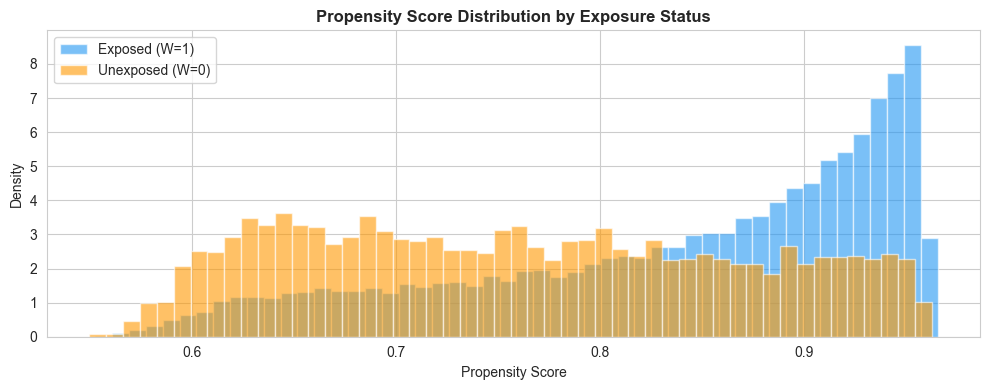

In [9]:
# Visualize propensity score overlap
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(df_ipw[df_ipw['exposed']==1]['ps'], bins=50, alpha=0.6, label='Exposed (W=1)', color='#2196F3', density=True)
ax.hist(df_ipw[df_ipw['exposed']==0]['ps'], bins=50, alpha=0.6, label='Unexposed (W=0)', color='#FF9800', density=True)
ax.set_xlabel('Propensity Score')
ax.set_ylabel('Density')
ax.set_title('Propensity Score Distribution by Exposure Status', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

In [10]:
# Step 2: Compute ATT weights with clipping at 99th percentile
df_ipw['w_att'] = np.where(
    df_ipw['exposed'] == 1,
    1.0,
    df_ipw['ps'] / (1 - df_ipw['ps'])
)

# Trim extreme weights
cap = np.percentile(df_ipw['w_att'], 99)
df_ipw['w_att'] = df_ipw['w_att'].clip(upper=cap)

print(f'Weight clipping threshold (99th pct): {cap:.4f}')
print(f'\nWeight distribution after trimming:')
print(df_ipw.groupby('exposed')['w_att'].describe().round(4))

Weight clipping threshold (99th pct): 14.1110

Weight distribution after trimming:
           count    mean     std     min     25%     50%     75%     max
exposed                                                                 
0         4341.0  4.5518  3.6037  1.2197  2.0045  3.0733  5.5819  14.111
1        20659.0  1.0000  0.0000  1.0000  1.0000  1.0000  1.0000   1.000


In [11]:
# Step 3: Estimate ATT via weighted regression
ipw_model = smf.wls(
    formula='converted ~ exposed',
    data=df_ipw,
    weights=df_ipw['w_att']
).fit()

ipw_abs = ipw_model.params['exposed']

# Baseline: weighted average conversion rate for unexposed users
unexposed_ipw = df_ipw[df_ipw['exposed'] == 0]
baseline_ipw = np.average(unexposed_ipw['converted'], weights=unexposed_ipw['w_att'])
ipw_rel = ipw_abs / baseline_ipw

print('=== Inverse Probability Weighting ===')
print(f'  IPW Absolute Lift:              {ipw_abs:.4f}')
print(f'  IPW Relative Lift:              {ipw_rel:.2%}')
print(f'  95% CI:                         [{ipw_model.conf_int().loc["exposed", 0]:.4f}, {ipw_model.conf_int().loc["exposed", 1]:.4f}]')
print(f'\n  Experimental ATT (benchmark):   {att_exp:.4f} ({att_exp/conv_c_exposed:.2%} relative)')

=== Inverse Probability Weighting ===
  IPW Absolute Lift:              0.1252
  IPW Relative Lift:              88.61%
  95% CI:                         [0.1153, 0.1351]

  Experimental ATT (benchmark):   0.0547 (25.85% relative)


### Findings

The IPW estimate offers an improvement over the naive comparison and is in the direction of the experimental ATT. The propensity score overlap plot is critical here: if both exposed and unexposed users share similar propensity score distributions (the "common support" assumption), the IPW reweighting is credible. Thin overlap regions — where propensity scores for exposed and unexposed users barely intersect — would indicate that some user segments lack valid counterfactuals, weakening the estimate.

The residual discrepancy between the IPW estimate and the experimental ATT reflects the fundamental limitation of observational methods: IPW can only balance on **observed** covariates. The multiple sources of endogeneity in digital advertising — including platform-level behavioral signals, real-time auction dynamics, and unobserved user intent — are not fully captured by the available variables, leaving residual confounding that IPW cannot correct.

---

## Question 6: Double Machine Learning (Double ML)

### Conceptual Background

Double Machine Learning (Chernozhukov et al., 2018) is a semiparametric causal inference method designed to obtain near-unbiased estimates of treatment effects in the presence of high-dimensional or non-linearly structured nuisance parameters.

The core insight of Double ML is **orthogonalization**: rather than directly regressing the outcome on treatment and controls, it first residualizes both the outcome and the treatment variable with respect to the covariate set, then estimates the treatment effect from the residualized relationship. This two-stage approach removes the influence of nuisance parameters — the complex functions linking covariates to both exposure and outcome — thereby eliminating the regularization bias that would arise from using machine learning models directly in a single regression.

**The two-stage procedure:**

1. **Outcome model:** Fit a machine learning model $\hat{\ell}(X) = E[Y | X]$ using only covariates (no treatment). Compute outcome residuals: $\tilde{Y}_i = Y_i - \hat{\ell}(X_i)$.
2. **Treatment model:** Fit a machine learning model $\hat{m}(X) = E[W | X]$ using only covariates. Compute treatment residuals: $\tilde{W}_i = W_i - \hat{m}(X_i)$.
3. **Final estimate:** Regress $\tilde{Y}$ on $\tilde{W}$ to obtain the treatment effect coefficient.

**Cross-fitting** is applied to prevent overfitting bias: the data is split into folds, nuisance models are trained on out-of-fold data, and residuals are computed on held-out samples. We use the `DoubleMLIRM` (Interactive Regression Model) specification with `score='ATTE'` to target the ATT estimand.

In [12]:
try:
    import doubleml as dml
    from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
    print('doubleml loaded successfully.')
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'doubleml', '-q'])
    import doubleml as dml
    from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
    print('doubleml installed and loaded.')

doubleml loaded successfully.


In [13]:
x_cols = ['age', 'gender', 'activity', 'num_friends', 'time_on_platform',
          'mobile_frac', 'prior_conversion', 'income', 'urban_index']
y_col = 'converted'
d_col = 'exposed'

dml_data = dml.DoubleMLData(
    treatment[x_cols + [y_col, d_col]].reset_index(drop=True),
    y_col=y_col,
    d_cols=d_col,
    x_cols=x_cols
)

ml_g = RandomForestRegressor(n_estimators=100, max_depth=6, random_state=42, n_jobs=-1)
ml_m = RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42, n_jobs=-1)

dml_irm = dml.DoubleMLIRM(
    dml_data,
    ml_g=ml_g,
    ml_m=ml_m,
    score='ATTE',
    n_folds=3,
    n_rep=1
)

print('Fitting Double ML model (this may take several minutes)...')
dml_irm.fit()
print('Done.')

Fitting Double ML model (this may take several minutes)...


Done.


In [14]:
dml_abs = dml_irm.coef[0]

# Baseline: predicted conversion rate of exposed users if unexposed
# Use the adjusted regression model's counterfactual as a proxy for the baseline
baseline_dml = exposed_ar['pred_without_ad'].mean()
dml_rel = dml_abs / baseline_dml

print('=== Double Machine Learning ===')
print(dml_irm.summary)
print(f'\n  DML Absolute Lift:              {dml_abs:.4f}')
print(f'  DML Relative Lift:              {dml_rel:.2%}')
print(f'\n  Experimental ATT (benchmark):   {att_exp:.4f} ({att_exp/conv_c_exposed:.2%} relative)')

=== Double Machine Learning ===
             coef   std err          t         P>|t|     2.5 %    97.5 %
exposed  0.122547  0.007257  16.886421  5.663611e-64  0.108323  0.136771

  DML Absolute Lift:              0.1225
  DML Relative Lift:              83.69%

  Experimental ATT (benchmark):   0.0547 (25.85% relative)


### Findings

The Double ML estimate leverages the flexibility of Random Forest models to capture non-linear and interaction effects among covariates — relationships that logistic regression (used in Q4 and Q5) may inadequately approximate. The cross-fitting procedure ensures that the nuisance estimates are unbiased with respect to the final treatment effect estimation, providing a doubly-robust property: the ATT estimate is consistent as long as at least one of the two nuisance models (outcome or treatment) is correctly specified.

Double ML represents the most sophisticated observational estimator in this analysis and is expected to most closely approximate the experimental ATT. The confidence interval reported in the summary indicates the precision of this estimate, providing uncertainty quantification that is absent from the simpler methods.

---

## Question 7: Overall Conclusion and Key Learnings

### Comparative Results Summary

In [15]:
summary = pd.DataFrame({
    'Method': [
        'Experimental ATT (RCT Benchmark)',
        'Naive Comparison',
        'Adjusted Regression',
        'Inverse Probability Weighting',
        'Double Machine Learning'
    ],
    'Absolute Lift': [
        att_exp,
        naive_abs,
        ar_abs,
        ipw_abs,
        dml_abs
    ],
    'Relative Lift': [
        att_exp / conv_c_exposed,
        naive_rel,
        ar_rel,
        ipw_rel,
        dml_rel
    ],
    'Bias vs. ATT (absolute)': [
        0,
        naive_abs - att_exp,
        ar_abs - att_exp,
        ipw_abs - att_exp,
        dml_abs - att_exp
    ]
})

summary['Absolute Lift'] = summary['Absolute Lift'].map('{:.4f}'.format)
summary['Relative Lift'] = summary['Relative Lift'].map('{:.2%}'.format)
summary['Bias vs. ATT (absolute)'] = summary['Bias vs. ATT (absolute)'].map('{:+.4f}'.format)
summary.set_index('Method')

,Absolute Lift,Relative Lift,Bias vs. ATT (absolute)
Method,,,
Experimental ATT (RCT Benchmark),0.0547,25.85%,+0.0000
Naive Comparison,0.1608,152.11%,+0.1061
Adjusted Regression,0.1201,82.04%,+0.0654
Inverse Probability Weighting,0.1252,88.61%,+0.0705
Double Machine Learning,0.1225,83.69%,+0.0678


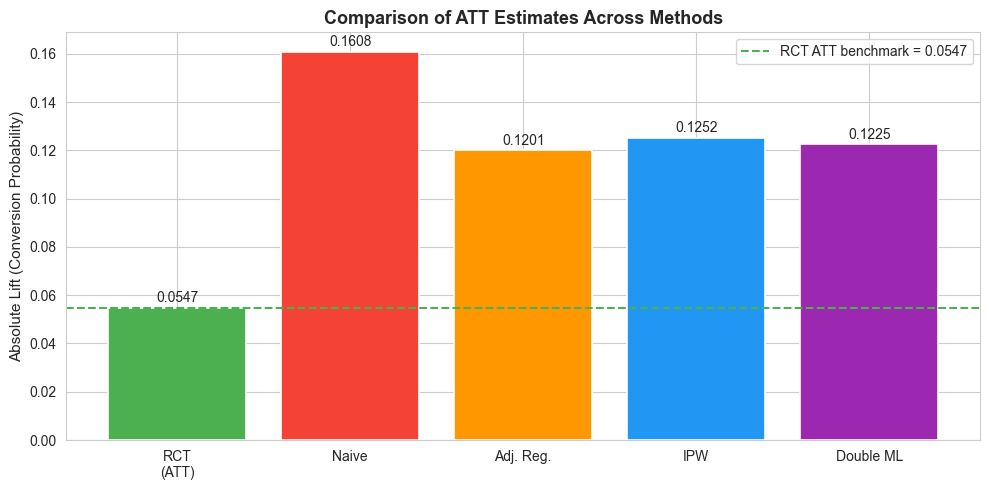

In [16]:
methods = ['RCT\n(ATT)', 'Naive', 'Adj. Reg.', 'IPW', 'Double ML']
abs_lifts = [att_exp, naive_abs, ar_abs, ipw_abs, dml_abs]
colors = ['#4CAF50', '#f44336', '#FF9800', '#2196F3', '#9C27B0']

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(methods, abs_lifts, color=colors, edgecolor='white', linewidth=1.2)
ax.axhline(att_exp, color='#4CAF50', linestyle='--', linewidth=1.5, label=f'RCT ATT benchmark = {att_exp:.4f}')
ax.set_ylabel('Absolute Lift (Conversion Probability)', fontsize=11)
ax.set_title('Comparison of ATT Estimates Across Methods', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
for bar, val in zip(bars, abs_lifts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001, f'{val:.4f}',
            ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

### Discussion

#### What the Experimental Results Revealed

The RCT provides a clean, unconfounded estimate of the causal effect of ad exposure on conversion. The ATT — measuring the lift specifically among users who received the ad — represents the true incremental value of the advertising campaign for the exposed population. The ITT, being smaller, reflects the dilution from non-compliant users (those assigned to treatment but not exposed), and is the more conservative estimate of campaign-level impact.

#### How Observational Methods Compare

The results trace a clear progression in the accuracy of causal estimation:

- **Naive Comparison** produces the largest overestimate of lift. This is a direct consequence of the three forms of endogeneity discussed in Appendix A of the case: activity bias, targeting-induced endogeneity, and competition-induced endogeneity all work in the same direction — making exposed users systematically higher-propensity converters than unexposed users.

- **Adjusted Regression** substantially reduces bias by controlling for observed covariates in a parametric model. However, the linear-in-log-odds functional form assumption and the inability to model complex interactions limit its effectiveness. Residual bias persists wherever the true propensity-to-convert function is non-linear or where important confounders are unobserved.

- **Inverse Probability Weighting** improves upon adjusted regression by directly balancing the covariate distribution rather than assuming a parametric outcome model. Nonetheless, it inherits the same fundamental limitation: it can only balance on observable characteristics, leaving unobserved confounders intact.

- **Double Machine Learning** achieves the closest approximation to the experimental ATT among the observational methods. By leveraging non-parametric machine learning for nuisance estimation and applying orthogonalization to remove regularization bias, Double ML relaxes the functional form assumptions of both regression adjustment and IPW.

#### Implications for Digital Advertising Measurement

These findings carry important practical implications. The naive comparison — the most commonly deployed approach in practice — produces estimates that are materially misleading. The overestimation can lead firms to over-invest in advertising, misattribute conversions, and mis-allocate budget across channels.

Modern observational methods such as Double ML substantially close the gap with experimental estimates and represent a viable alternative when RCTs are cost-prohibitive. However, the residual bias that persists — attributable to unobserved confounders inherent to digital advertising platforms — underscores an important boundary condition: **observational methods can approximate, but not fully replicate, the causal rigor of well-designed experiments**.

The Ghost Ads methodology employed in this study represents a practical middle ground: by using the RCT framework to validate observational estimators and quantify their bias, practitioners can develop calibrated confidence in when and how much to trust observational estimates in contexts where experimentation is infeasible.

---

### References

- Chernozhukov, V., Chetverikov, D., Demirer, M., Duflo, E., Hansen, C., Newey, W., & Robins, J. (2018). Double/debiased machine learning for treatment and structural parameters. *The Econometrics Journal*, 21(1), C1–C68.
- Gordon, B. R., Moakler, R., & Zettelmeyer, F. (2023). Close enough? A large-scale exploration of non-experimental approaches to advertising measurement. *Marketing Science*, 42(4), 768–793.
- Lewis, R. A., Rao, J. M., & Reiley, D. H. (2011). Here, there, and everywhere: Correlated online behaviors can lead to overestimates of the effects of advertising. *Proceedings of the 20th International Conference on World Wide Web*, 157–166.